In [18]:
!pip install astra-toolbox

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from scipy import io
import astra
import time
from PIL import Image


--- Realizando pré-processamento ---
Sinograma reduzido: (1500, 512)


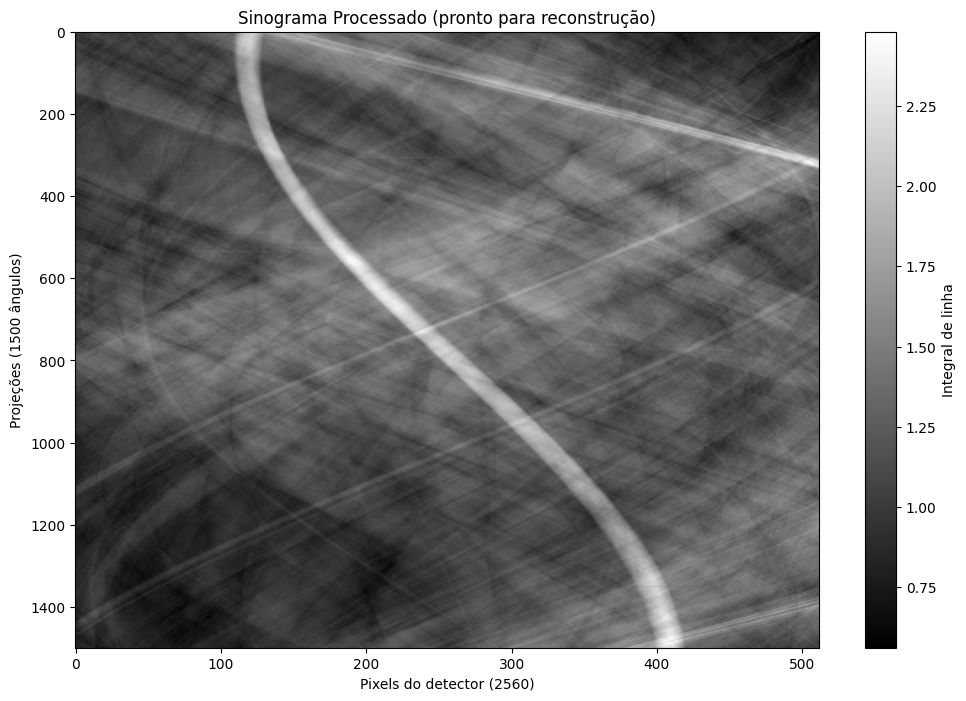

In [21]:
# Carregar o arquivo .mat
mat_data = io.loadmat('slice_1080_data.mat')

# Extrair os dados e transpor para o formato correto: (n_angles, n_detector)
X_dark = mat_data['X_dark'].T # (dark_images, pixels)
X_flat = mat_data['X_flat'].T # (flat_images, pixels)
X_proj = mat_data['X_proj'].T # (projections, pixels)

# ------------ Pré-processamento (correção de dark e flat) -------------------

# Calcular médias ao longo das imagens (axis=0)
dark_mean = np.mean(X_dark, axis=0)
flat_mean = np.mean(X_flat, axis=0)

# Corrigir cada projeção: I_corrected = (I_raw - dark) / (flat - dark)
# Adicionar pequeno valor para evitar divisão por zero
denominator = flat_mean - dark_mean
denominator = np.where(denominator < 1e-6, 1e-6, denominator)
sinogram_corrected = np.zeros_like(X_proj, dtype=np.float32)
for i in range(X_proj.shape[0]):
    sinogram_corrected[i] = (X_proj[i] - dark_mean) / denominator

# Clip para evitar valores negativos ou muito pequenos
sinogram_corrected = np.clip(sinogram_corrected, 1e-6, None)

# Aplicar -log, garantindo valores positivos
sinogram_processed = -np.log(np.maximum(sinogram_corrected, 1e-8))

# Configurar geometria para reconstrução
n_detector = X_proj.shape[1]      # Número de pixels no detector: 2560
n_angles = X_proj.shape[0]        # Número de projeções: 1500
angles = np.linspace(0, np.pi, n_angles, endpoint=False)

# 2560x2560 é muito grande, reduzindo resolução para 512x512
recon_size = 512

# Subamostrar o sinograma para tamanho menor
sinogram_small = resize(sinogram_processed, (n_angles, recon_size), preserve_range=True)
b = sinogram_small
print(f"Sinograma reduzido: {b.shape}")

# Visualizar sinograma processado
plt.figure(figsize=(12, 8))
plt.imshow(b, cmap='gray', aspect='auto')
plt.title('Sinograma Processado (pronto para reconstrução)')
plt.xlabel('Pixels do detector (2560)')
plt.ylabel('Projeções (1500 ângulos)')
plt.colorbar(label='Integral de linha')
plt.show()

In [22]:
# Geometria para ASTRA com tamanho reduzido
vol_geom = astra.create_vol_geom(recon_size, recon_size)
proj_geom = astra.create_proj_geom('parallel', 1.0, recon_size, angles)

# Criar projetor
projector_id = astra.create_projector('linear', proj_geom, vol_geom)

In [23]:
def A(x):
    _, sinogram = astra.create_sino(x, projector_id)
    return sinogram

def AT(y):
    _, backproj = astra.create_backprojection(y, projector_id)
    return backproj

def f(x):
    return 0.5 * np.linalg.norm(A(x) - b)**2

def grad(x):
    Ax = A(x)
    return AT(Ax - b)

def exact_step(x):
    g = grad(x)
    Ag = A(g)
    ATAg = AT(Ag)
    num = np.sum(g * g)
    den = np.sum(g * ATAg)
    return num / den if den > 0 else 0.01

def descent_grad(x0=None, Lambda=None, iters=10):
    x = np.zeros((recon_size, recon_size), dtype=np.float32)
    x_values = []

    for i in range(iters):
        if Lambda is None:
            step = exact_step(x)
        else:
            step = Lambda

        x = x - step * grad(x)
        x_values.append(x)

    return x_values

In [24]:
# Executar reconstrução
start = time.time()
x_values = descent_grad(iters=50)
reconstruction = x_values[-1]
end = time.time()
print(f"Tempo de reconstrução: {end - start:.2f} segundos")

Tempo de reconstrução: 1125.74 segundos


In [ ]:
# Valores de f(x)
f_values = [f(x) for x in x_values]

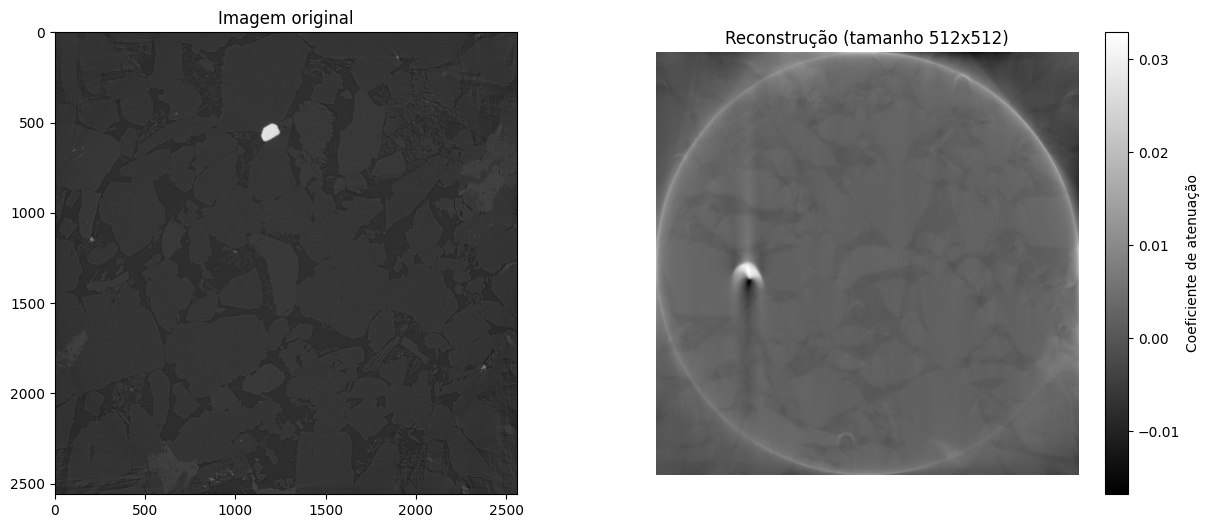

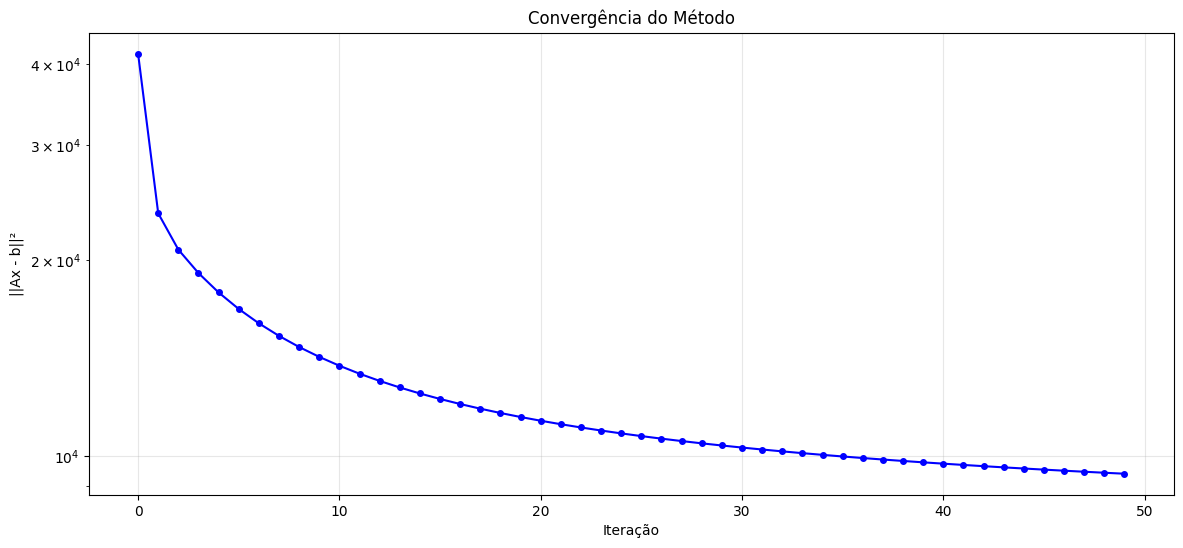

In [38]:
# Visualizar resultado

# Carregando imagem original
image = Image.open('recon/BBii_1080.rec.16bit.tif' )

plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagem original')

plt.subplot(1, 2, 2)
plt.imshow(reconstruction, cmap='gray')
plt.title(f'Reconstrução (tamanho {recon_size}x{recon_size})')
plt.colorbar(label='Coeficiente de atenuação')
plt.axis('off')
plt.show()

# Evolução de F(x)
plt.figure(figsize=(14, 6))
plt.semilogy(f_values, 'b-o', markersize=4)
plt.xlabel('Iteração')
plt.ylabel('||Ax - b||²')
plt.title('Convergência do Método')
plt.grid(True, alpha=0.3)
plt.show()
